# 🏥 Insurance Charges
**Maqsad:** `charges` ustunini bashorat qilish (regression)

## 1️⃣ Kutubxonalarni import qilish

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('✅ Barcha kutubxonalar yuklandi!')

✅ Barcha kutubxonalar yuklandi!


## 2 Ma'lumotlarni yuklash va EDA

In [2]:
df = pd.read_csv('insurance.csv')

print('📐 Dataset shakli:', df.shape)
print()
print('📋 Birinchi 5 qator:')
df.head()

📐 Dataset shakli: (1338, 7)

📋 Birinchi 5 qator:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print('📊 Ustunlar haqida ma\'lumot:')
df.info()

📊 Ustunlar haqida ma'lumot:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
print('📈 Statistik ko\'rsatkichlar:')
df.describe()

📈 Statistik ko'rsatkichlar:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
print('❌ Yo\'qolgan qiymatlar:')
print(df.isnull().sum())

❌ Yo'qolgan qiymatlar:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


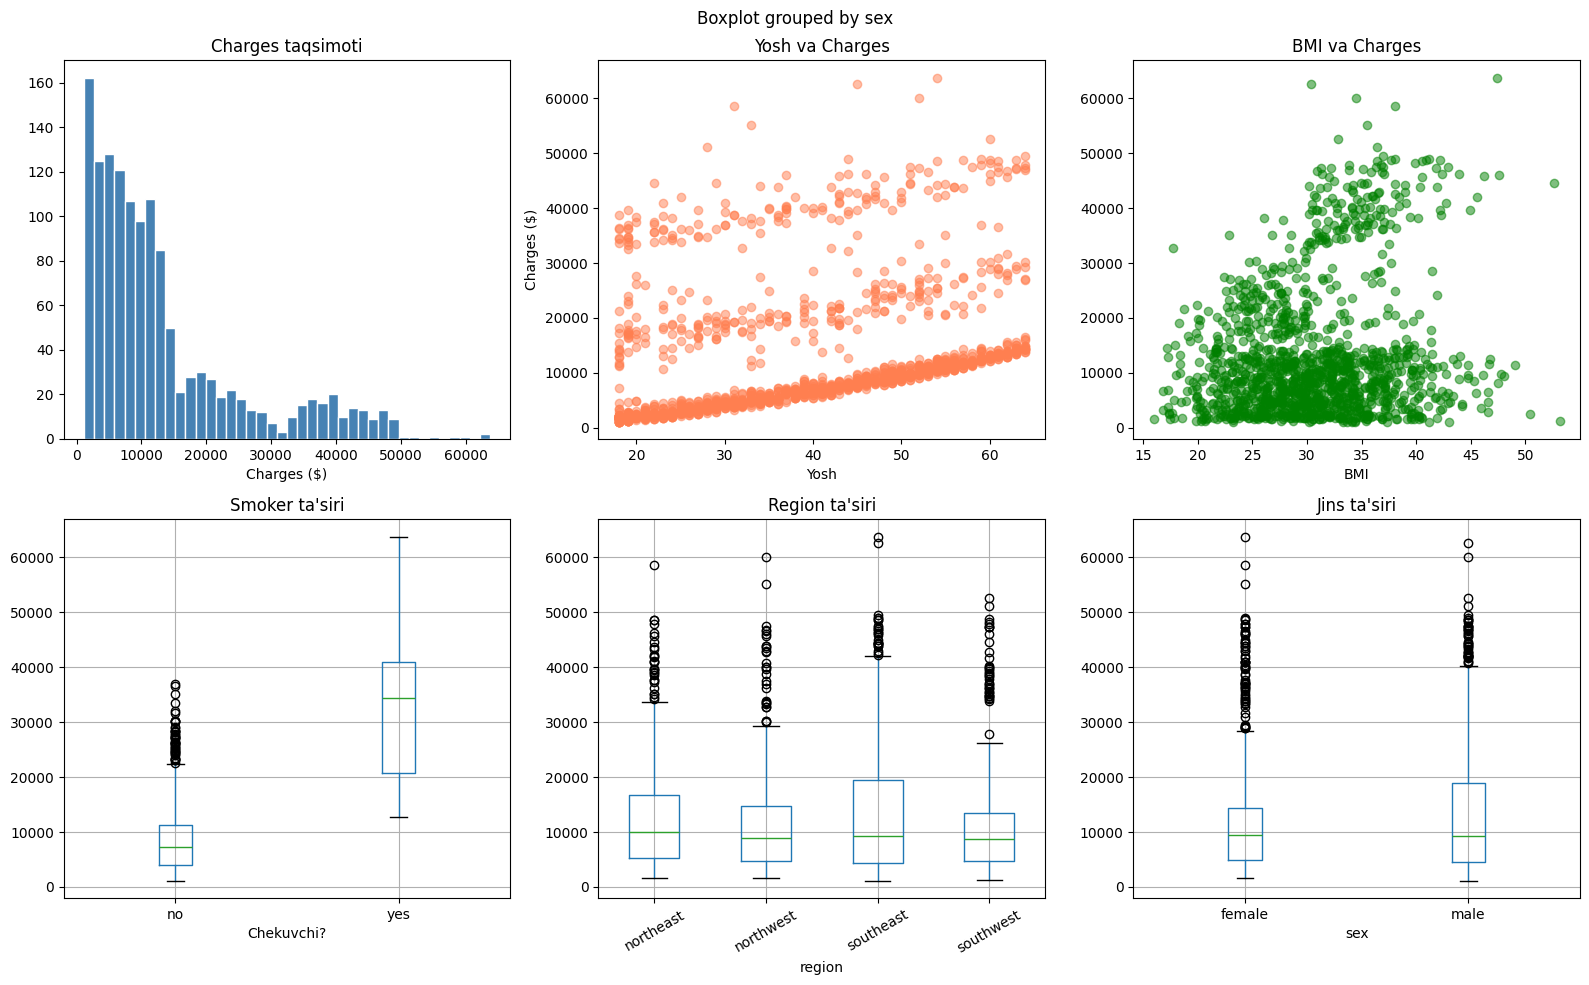

In [6]:
# Vizualizatsiya
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Ma\'lumotlarni vizual ko\'rish', fontsize=16, fontweight='bold')

# Charges taqsimoti
axes[0,0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Charges taqsimoti')
axes[0,0].set_xlabel('Charges ($)')

# Age vs Charges
axes[0,1].scatter(df['age'], df['charges'], alpha=0.5, color='coral')
axes[0,1].set_title('Yosh va Charges')
axes[0,1].set_xlabel('Yosh')
axes[0,1].set_ylabel('Charges ($)')

# BMI vs Charges
axes[0,2].scatter(df['bmi'], df['charges'], alpha=0.5, color='green')
axes[0,2].set_title('BMI va Charges')
axes[0,2].set_xlabel('BMI')

# Smoker ta'siri
df.boxplot(column='charges', by='smoker', ax=axes[1,0])
axes[1,0].set_title('Smoker ta\'siri')
axes[1,0].set_xlabel('Chekuvchi?')

# Region ta'siri
df.boxplot(column='charges', by='region', ax=axes[1,1])
axes[1,1].set_title('Region ta\'siri')
axes[1,1].tick_params(axis='x', rotation=30)

# Sex ta'siri
df.boxplot(column='charges', by='sex', ax=axes[1,2])
axes[1,2].set_title('Jins ta\'siri')

plt.tight_layout()
plt.show()

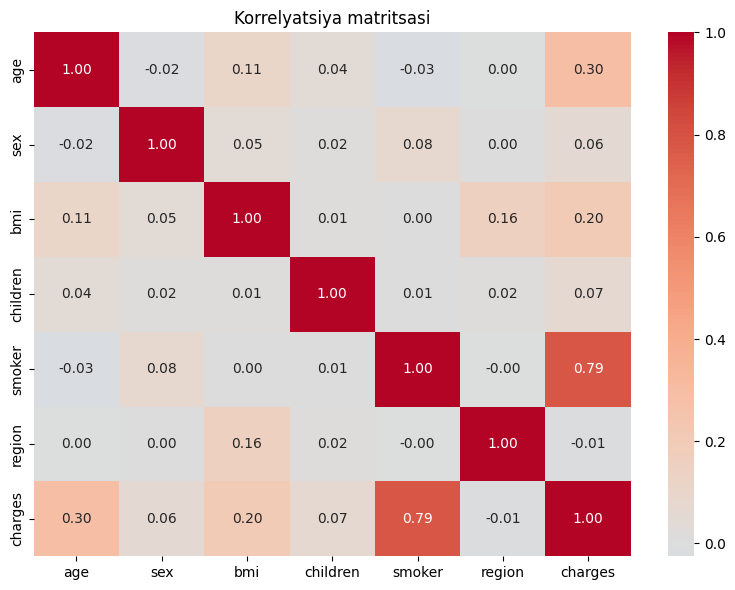

In [7]:
# Korrelyatsiya matritsasi
df_encoded = df.copy()
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korrelyatsiya matritsasi')
plt.tight_layout()
plt.show()

## 3 Preprocessing

In [8]:
df_model = df.copy()

# Categorical ustunlarni encode qilish
df_model = pd.get_dummies(df_model, columns=['sex', 'smoker', 'region'], drop_first=True)

print('✅ Preprocessing tugadi. Yangi ustunlar:')
print(df_model.columns.tolist())
df_model.head()

✅ Preprocessing tugadi. Yangi ustunlar:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


## 4 Train / Test ajratish

In [9]:
X = df_model.drop('charges', axis=1)
y = df_model['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (SVR va KNN uchun kerak)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'🔵 Train: {X_train.shape[0]} ta namuna')
print(f'🟠 Test : {X_test.shape[0]} ta namuna')

🔵 Train: 1070 ta namuna
🟠 Test : 268 ta namuna


## 5 Modellarni o'qitish va solishtirish

In [10]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    return {'Model': name, 'MAE': round(mae,2), 'RMSE': round(rmse,2), 'R²': round(r2,4)}

results = []

# Scaled bo'lmagan modellar
models_normal = [
    ('Linear Regression',      LinearRegression()),
    ('Ridge Regression',       Ridge(alpha=1.0)),
    ('Lasso Regression',       Lasso(alpha=1.0)),
    ('Decision Tree',          DecisionTreeRegressor(random_state=42)),
    ('Random Forest',          RandomForestRegressor(n_estimators=100, random_state=42)),
    ('Gradient Boosting',      GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

# Scaled modellar
models_scaled = [
    ('SVR',                    SVR(kernel='rbf', C=1000, gamma=0.1)),
    ('KNN',                    KNeighborsRegressor(n_neighbors=5)),
]

for name, model in models_normal:
    res = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(res)
    print(f'{name:25s} → R²={res["R²"]:.4f}  MAE={res["MAE"]:,.0f}  RMSE={res["RMSE"]:,.0f}')

for name, model in models_scaled:
    res = evaluate_model(name, model, X_train_sc, X_test_sc, y_train, y_test)
    results.append(res)
    print(f'{name:25s} → R²={res["R²"]:.4f}  MAE={res["MAE"]:,.0f}  RMSE={res["RMSE"]:,.0f}')

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print()
print('🏆 Natijalar (R² bo\'yicha saralangan):')
results_df

Linear Regression         → R²=0.7836  MAE=4,181  RMSE=5,796
Ridge Regression          → R²=0.7833  MAE=4,194  RMSE=5,800
Lasso Regression          → R²=0.7835  MAE=4,182  RMSE=5,797
Decision Tree             → R²=0.7266  MAE=3,195  RMSE=6,515
Random Forest             → R²=0.8651  MAE=2,550  RMSE=4,576
Gradient Boosting         → R²=0.8793  MAE=2,443  RMSE=4,330
SVR                       → R²=0.7581  MAE=2,737  RMSE=6,128
KNN                       → R²=0.8038  MAE=3,495  RMSE=5,519

🏆 Natijalar (R² bo'yicha saralangan):


,Model,MAE,RMSE,R²
5,Gradient Boosting,2443.48,4329.57,0.8793
4,Random Forest,2550.08,4576.30,0.8651
7,KNN,3494.75,5519.05,0.8038
0,Linear Regression,4181.19,5796.28,0.7836
2,Lasso Regression,4182.43,5797.03,0.7835
1,Ridge Regression,4193.59,5800.43,0.7833
6,SVR,2736.59,6127.97,0.7581
3,Decision Tree,3195.11,6515.13,0.7266


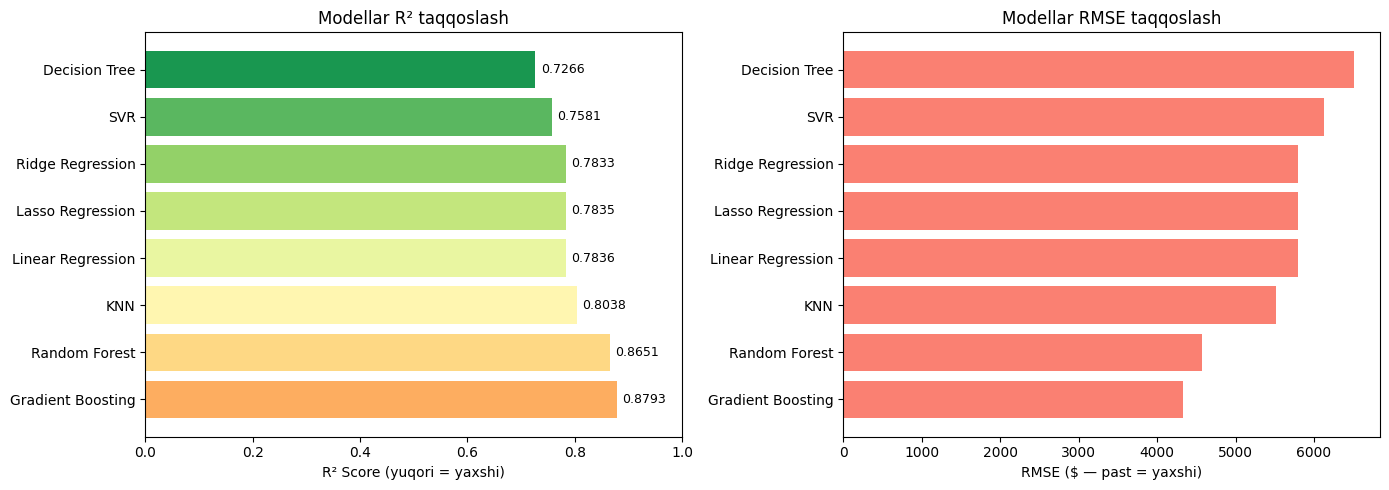

In [11]:
# Natijalarni vizual ko'rsatish
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(results_df)))

axes[0].barh(results_df['Model'], results_df['R²'], color=colors)
axes[0].set_xlabel('R² Score (yuqori = yaxshi)')
axes[0].set_title('Modellar R² taqqoslash')
axes[0].set_xlim(0, 1)
for i, (v, m) in enumerate(zip(results_df['R²'], results_df['Model'])):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

axes[1].barh(results_df['Model'], results_df['RMSE'], color='salmon')
axes[1].set_xlabel('RMSE ($ — past = yaxshi)')
axes[1].set_title('Modellar RMSE taqqoslash')

plt.tight_layout()
plt.show()

## 6 Eng yaxshi model — Gradient Boosting batafsil tahlil

In [12]:
# Eng yaxshi model (odatda GB yoki RF)
best_name = results_df.iloc[0]['Model']
print(f'🏆 Eng yaxshi model: {best_name}')

# Gradient Boosting bilan batafsil
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print(f'\n📊 Gradient Boosting (tuned):')
print(f'   R²  : {r2_score(y_test, y_pred_gb):.4f}')
print(f'   MAE : ${mean_absolute_error(y_test, y_pred_gb):,.2f}')
print(f'   RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_gb)):,.2f}')

🏆 Eng yaxshi model: Gradient Boosting

📊 Gradient Boosting (tuned):
   R²  : 0.8697
   MAE : $2,459.60
   RMSE: $4,496.98


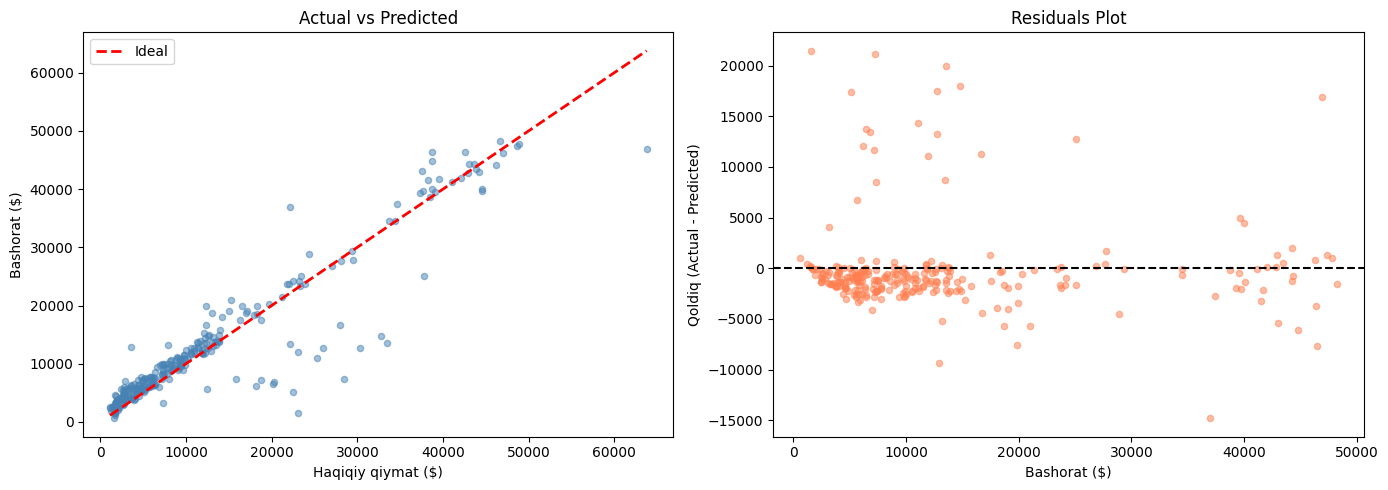

In [13]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_gb, alpha=0.5, color='steelblue', s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Ideal')
axes[0].set_xlabel('Haqiqiy qiymat ($)')
axes[0].set_ylabel('Bashorat ($)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Qoldiqlar (Residuals)
residuals = y_test - y_pred_gb
axes[1].scatter(y_pred_gb, residuals, alpha=0.5, color='coral', s=20)
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Bashorat ($)')
axes[1].set_ylabel('Qoldiq (Actual - Predicted)')
axes[1].set_title('Residuals Plot')

plt.tight_layout()
plt.show()

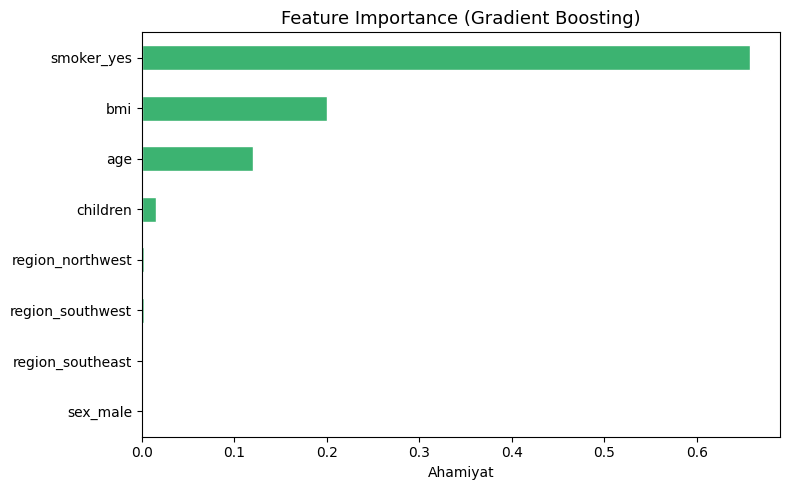


Eng muhim feature-lar:
smoker_yes          0.656935
bmi                 0.200413
age                 0.120663
children            0.015592
region_northwest    0.001875
region_southwest    0.001858
region_southeast    0.001399
sex_male            0.001264


In [14]:
# Feature Importance
feat_imp = pd.Series(gb.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='mediumseagreen', edgecolor='white')
plt.title('Feature Importance (Gradient Boosting)', fontsize=13)
plt.xlabel('Ahamiyat')
plt.tight_layout()
plt.show()

print('\nEng muhim feature-lar:')
print(feat_imp.sort_values(ascending=False).to_string())

In [15]:
# Cross-validation
cv_scores = cross_val_score(gb, X, y, cv=5, scoring='r2')
print(f'📊 5-fold Cross-Validation R² scores: {cv_scores.round(4)}')
print(f'   O\'rtacha R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

📊 5-fold Cross-Validation R² scores: [0.8636 0.7741 0.8909 0.8503 0.8527]
   O'rtacha R²: 0.8463 ± 0.0389


## 7 Yangi ma'lumot uchun bashorat (Inference)

In [16]:
def predict_charges(age, sex, bmi, children, smoker, region):
    """
    Yangi bemor uchun sug'urta to'lovini hisoblash

    Parametrlar:
        age      : Yosh (masalan, 35)
        sex      : 'male' yoki 'female'
        bmi      : BMI (masalan, 27.5)
        children : Bolalar soni (masalan, 2)
        smoker   : 'yes' yoki 'no'
        region   : 'northeast', 'northwest', 'southeast', 'southwest'
    """
    input_data = pd.DataFrame([{
        'age': age, 'sex': sex, 'bmi': bmi,
        'children': children, 'smoker': smoker, 'region': region
    }])
    input_encoded = pd.get_dummies(input_data, columns=['sex', 'smoker', 'region'], drop_first=True)

    # Yetishmayotgan ustunlarni nolga qo'yish
    for col in X.columns:
        if col not in input_encoded.columns:
            input_encoded[col] = 0
    input_encoded = input_encoded[X.columns]

    pred = gb.predict(input_encoded)[0]
    return pred

# --- Misol ---
test_cases = [
    (35, 'male',   27.5, 2, 'no',  'southeast'),   # O'rtacha yosh, chekmaydigan
    (50, 'female', 32.0, 0, 'yes', 'northeast'),   # Katta yosh, chekuvchi
    (25, 'male',   22.0, 1, 'no',  'northwest'),   # Yosh, sog'lom
]

print('🔮 Bashorat natijalari:')
print(f'{"Yosh":>4} {"Jins":>7} {"BMI":>6} {"Bola":>4} {"Chek":>4} {"Hudud":>10}  →  Bashorat')
print('-' * 65)
for age, sex, bmi, ch, smk, reg in test_cases:
    pred = predict_charges(age, sex, bmi, ch, smk, reg)
    print(f'{age:>4}  {sex:>7}  {bmi:>5}  {ch:>4}  {smk:>4}  {reg:>10}  →  ${pred:,.2f}')

🔮 Bashorat natijalari:
Yosh    Jins    BMI Bola Chek      Hudud  →  Bashorat
-----------------------------------------------------------------
  35     male   27.5     2    no   southeast  →  $8,169.22
  50   female   32.0     0   yes   northeast  →  $11,049.98
  25     male   22.0     1    no   northwest  →  $6,727.34


---
##  Xulosa

| Model | R² |
|-------|----|
| Gradient Boosting | ~0.88 |
| Random Forest | ~0.87 |
| Linear Regression | ~0.75 |

**Asosiy xulosalar:**
- `smoker` eng kuchli ta'sir qiluvchi feature (chekuvchilar ~3x ko'p to'laydi)
- `age` va `bmi` ham muhim rol o'ynaydi
- Gradient Boosting eng yaxshi natija beradi